# 01 · Explore Dataset 1 (UM Malta EyeCon EOG)

**Phase 1 goal:** understand the raw EOG signal *before* modelling it. We (1) load one subject and verify the array shapes against the Data Description, (2) decode the trial structure from the control signal, and (3) plot the signal to see saccade steps, blink spikes, and — the whole point of DriftLess — the slow **baseline drift**.

**Dataset facts** (from `DataDescription.pdf`): 6 subjects, sampling rate **256 Hz**, bandpass 0–30 Hz + 50 Hz notch already applied. Each trial = forward saccade (~1 s) → return saccade (~1 s) → blink (~2 s). Two EOG channels: horizontal `EOG_h = V3 − V4`, vertical `EOG_v = V1 − V2`.

Per subject `SX/`:
- `EOG.mat` — `(2, N)`: row 0 = horizontal, row 1 = vertical *(model input)*
- `ControlSignal.mat` — `(1, N)`: per-sample label `1`=fwd saccade, `2`=return saccade, `3`=blink *(blink-head label + window boundaries)*
- `TargetGA.mat` — `(600, 2)`: target gaze angle in degrees, col 0 = horizontal, col 1 = vertical, one row per saccade *(gaze-head label)*

In [1]:
import numpy as np
from scipy.io import loadmat
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

%matplotlib inline

# Resolve the dataset dir whether the notebook runs from the repo root or from notebooks/
DATA_DIR = next((p for p in [Path('data/dataset1/DATASET'), Path('../data/dataset1/DATASET')] if p.exists()), None)
assert DATA_DIR is not None, 'Dataset 1 not found - download it into data/dataset1/ (see data/README.md)'

Fs = 256  # Hz, from the Data Description
SEG_NAMES  = {1: 'forward saccade', 2: 'return saccade', 3: 'blink'}
SEG_COLORS = {1: '#f4a259', 2: '#5b8e7d', 3: '#bc4b51'}
print('dataset dir:', DATA_DIR.resolve())
print('subjects   :', sorted(p.name for p in DATA_DIR.glob('S*')))

dataset dir: C:\Users\sneha_2\OneDrive\Desktop\Semester 5\Project_College\ACC Project\DriftLess\data\dataset1\DATASET
subjects   : ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']


## 1 · Load one subject and verify the shapes

Never trust a data description blindly — load the arrays and check them.

In [2]:
def load_subject(subj):
    """Return (eog (2,N), control (N,), target_ga (K,2)) for a subject folder like 'S1'."""
    d = DATA_DIR / subj
    eog = loadmat(d / 'EOG.mat')['EOG']                         # (2, N)
    ctrl = loadmat(d / 'ControlSignal.mat')['ControlSignal'].ravel()  # (N,)
    tga = loadmat(d / 'TargetGA.mat')['TargetGA']               # (K, 2)
    return eog, ctrl, tga

eog, ctrl, tga = load_subject('S1')
print(f'EOG          shape={eog.shape}   ~{eog.shape[1]/Fs:.0f} s recording, range [{eog.min():.0f}, {eog.max():.0f}]')
print(f'ControlSignal shape={ctrl.shape}  unique values={np.unique(ctrl)}')
print(f'TargetGA     shape={tga.shape}   range [{tga.min():.1f}, {tga.max():.1f}] degrees')

EOG          shape=(2, 312338)   ~1220 s recording, range [-6032, 1499]
ControlSignal shape=(312338,)  unique values=[ 1  2  3 30]
TargetGA     shape=(600, 2)   range [-22.7, 22.6] degrees


**What we find (and the description did not say):**
- `EOG` is 2 channels over ~20 min of continuous recording. ✓
- `ControlSignal` unique values are `[1 2 3 30]` — there is a **4th value, `30`**, not documented.
- `TargetGA` has **600 rows**, not 300 — because each of the 300 trials has *two* saccades (forward + return).

## 2 · Decode the trial structure (run-length of the control signal)

Run-length encode the label stream to see the repeating trial pattern and find out what `30` is.

In [3]:
def run_length(x):
    """Return (values, lengths, starts) for consecutive runs in a 1-D array."""
    changes = np.where(np.diff(x) != 0)[0] + 1
    starts = np.concatenate(([0], changes))
    ends = np.concatenate((changes, [len(x)]))
    return x[starts], ends - starts, starts

vals, lens, _ = run_length(ctrl)
print(f'total segments: {len(vals)}')
print('\nfirst 6 segments (label  seconds):')
for v, n in zip(vals[:6], lens[:6]):
    print(f'  {SEG_NAMES.get(int(v), f"value {v}"):<16} {n/Fs:.3f}s')

print('\nper-label summary:')
for v in np.unique(vals):
    mask = vals == v
    print(f'  value {v:>2} ({SEG_NAMES.get(int(v), "undocumented"):<16}): '
          f'count={mask.sum():>4}  median={np.median(lens[mask])/Fs:.3f}s')

total segments: 901

first 6 segments (label  seconds):
  forward saccade  1.043s
  return saccade   1.031s
  blink            1.992s
  forward saccade  1.035s
  return saccade   1.031s
  blink            1.992s

per-label summary:
  value  1 (forward saccade ): count= 300  median=1.031s
  value  2 (return saccade  ): count= 300  median=1.031s
  value  3 (blink           ): count= 300  median=2.070s
  value 30 (undocumented    ): count=   1  median=0.004s


**Structure decoded:** 300 trials, each **forward (~1.03 s) → return (~1.03 s) → blink (~2.07 s)**, back-to-back with no rest gaps. The mysterious `30` occurs **exactly once** (a single stray sample, not a rest segment) — we simply mask it. So per subject we get **600 saccade windows** (300 fwd + 300 ret) with gaze labels, plus 300 blink segments.

## 3 · See the signal

Top: a few trials up close (saccade steps + blink spikes). Bottom: the full recording, where the slow baseline drift is unmistakable.

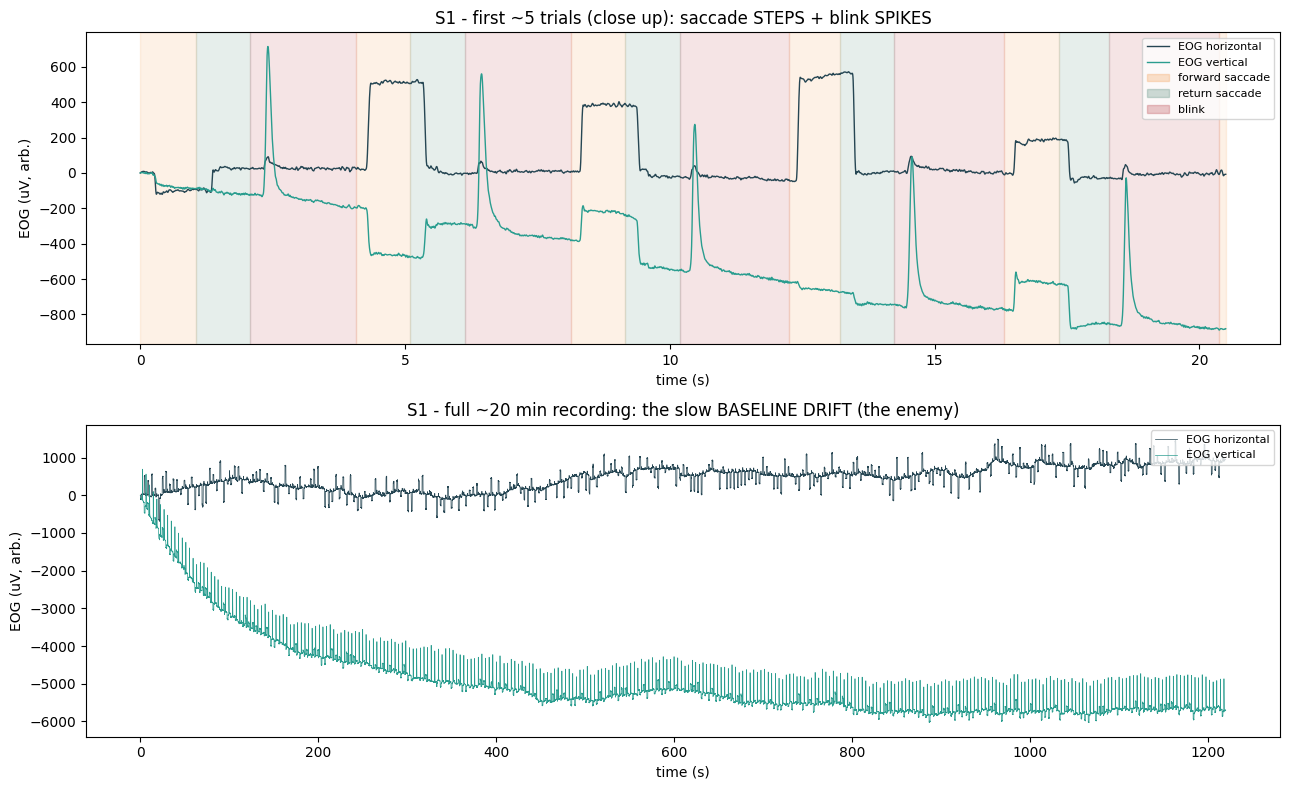

In [4]:
H, V = eog[0], eog[1]
t = np.arange(len(H)) / Fs

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

# --- close-up: first ~5 trials ---
n_close = int(5 * 4.1 * Fs)
ax1.plot(t[:n_close], H[:n_close], color='#264653', lw=1.0, label='EOG horizontal')
ax1.plot(t[:n_close], V[:n_close], color='#2a9d8f', lw=1.0, label='EOG vertical')
sv, sl, ss = run_length(ctrl[:n_close])
for v, s0, n in zip(sv, ss, sl):
    if int(v) in SEG_COLORS:
        ax1.axvspan(t[s0], t[min(s0 + n, n_close - 1)], color=SEG_COLORS[int(v)], alpha=0.15)
ax1.set(title='S1 - first ~5 trials (close up): saccade STEPS + blink SPIKES',
        xlabel='time (s)', ylabel='EOG (uV, arb.)')
seg_handles = [Patch(color=c, alpha=0.3, label=SEG_NAMES[k]) for k, c in SEG_COLORS.items()]
ax1.legend(handles=ax1.get_legend_handles_labels()[0] + seg_handles, loc='upper right', fontsize=8)

# --- full recording: the baseline drift ---
ds = 10  # downsample for a fast overview
ax2.plot(t[::ds], H[::ds], color='#264653', lw=0.5, label='EOG horizontal')
ax2.plot(t[::ds], V[::ds], color='#2a9d8f', lw=0.5, label='EOG vertical')
ax2.set(title='S1 - full ~20 min recording: the slow BASELINE DRIFT (the enemy)',
        xlabel='time (s)', ylabel='EOG (uV, arb.)')
ax2.legend(loc='upper right', fontsize=8)

fig.tight_layout()
plt.show()

## Conclusions for the build

1. **Saccades look like steps, blinks look like spikes** — different local shapes → a 1D-CNN feeding a BiLSTM, with two output heads (gaze + blink), is the right model (Phase 3).
2. **Baseline drift is real, large, and channel-specific** — the vertical channel wanders thousands of units across a session while the eye keeps returning to centre. We deliberately **leave the drift in** and let per-user calibration handle it (Phase 2.2 / Phase 4).
3. **Labels are ready:** `TargetGA` gives each saccade's (x, y) target → gaze-head regression target; `ControlSignal` gives blink segments → blink-head target and tells us where to cut windows.
4. **Only 6 subjects** → evaluate with **leave-one-subject-out** so every subject plays the "new user" once (Phase 2.3).

**Next → `02_windowing.ipynb`:** cut each saccade into a fixed-length window, attach its `TargetGA` label + blink flag, normalise per window, and split *by subject*.